In [3]:
%pip install --upgrade --force-reinstall \
  "numpy==1.26.4" \
  "scipy==1.14.0" \
  "torch==2.3.1" \
  "torchvision==0.18.1" \
  "torchaudio==2.3.1" \
  "gymnasium==1.2.3" \
  "stable-baselines3==2.7.1" \
  "matplotlib==3.9.1"

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.14.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached torch-2.3.1-cp311-cp311-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.18.1-cp311-cp311-manylinux1_x86_64.whl.metadata (6.6 kB)
  Using cached torchaudio-2.3.1-cp311-cp311-manylinux1_x86_64.whl.metadata (6.4 kB)
  Using cached gymnasium-1.2.3-py3-none-any.whl.metadata (10 kB)
  Using cached stable_baselines3-2.7.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached matplotlib-3.9.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-p

In [36]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

import torch

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv

In [37]:
SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA A40


In [38]:
class RacingFuelEnv:
    """
    Deterministic racing fuel environment.

    State:
        t      = current round
        fuel   = remaining fuel
        energy = current kinetic-energy-like quantity

    Action:
        burn   = litres burned this round

    Reward:
        distance_t = sqrt(energy_after_burn)

    Extension:
        carry-over can be constant or energy-dependent.
    """

    def __init__(
        self,
        horizon=10,
        init_fuel=100.0,
        energy_per_litre=1.0,
        friction=0.90,
        max_burn=30.0,
        retention_mode="constant",          # "constant" or "energy_dependent"
        drag_base_retention=0.95,
        drag_coeff=0.0035,
        drag_min_retention=0.55,
        drag_max_retention=0.95,
        seed=None
    ):
        self.horizon = int(horizon)
        self.init_fuel = float(init_fuel)
        self.energy_per_litre = float(energy_per_litre)
        self.friction = float(friction)
        self.max_burn = float(max_burn)

        self.retention_mode = retention_mode
        self.drag_base_retention = float(drag_base_retention)
        self.drag_coeff = float(drag_coeff)
        self.drag_min_retention = float(drag_min_retention)
        self.drag_max_retention = float(drag_max_retention)

        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.reset()

    def _obs(self):
        return np.array([self.t, self.fuel, self.energy], dtype=np.float32)

    def _retention_from_energy(self, energy_after):
        if self.retention_mode == "constant":
            return self.friction

        rho = self.drag_base_retention - self.drag_coeff * energy_after
        return float(np.clip(rho, self.drag_min_retention, self.drag_max_retention))

    def reset(self):
        self.t = 0
        self.fuel = float(self.init_fuel)
        self.energy = 0.0
        return self._obs()

    def step(self, burn):
        if self.t >= self.horizon:
            raise RuntimeError("Episode already finished. Call reset().")

        burn = float(np.clip(burn, 0.0, min(self.max_burn, self.fuel)))

        energy_after = self.energy + self.energy_per_litre * burn
        reward = float(np.sqrt(max(energy_after, 0.0)))

        retention = self._retention_from_energy(energy_after)
        energy_next = retention * energy_after

        self.energy = energy_next
        self.fuel -= burn
        self.t += 1

        done = (self.t >= self.horizon)

        info = {
            "burn": burn,
            "speed": reward,
            "distance": reward,
            "energy_after": energy_after,
            "energy_next": energy_next,
            "retention": retention,
            "fuel": self.fuel,
            "t": self.t
        }

        return self._obs(), reward, done, info

In [39]:
class RacingFuelDiscreteGymEnv(gym.Env):
    """
    Gymnasium wrapper for RacingFuelEnv with discrete burn actions.
    Suitable for DQN.
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        horizon=10,
        init_fuel=100.0,
        energy_per_litre=1.0,
        friction=0.90,
        max_burn=30.0,
        action_step_litres=1.0,
        normalize_obs=True,
        retention_mode="constant",
        drag_base_retention=0.95,
        drag_coeff=0.0035,
        drag_min_retention=0.55,
        drag_max_retention=0.95,
        energy_scale=150.0,
        seed=None
    ):
        super().__init__()

        self.horizon = int(horizon)
        self.init_fuel = float(init_fuel)
        self.energy_per_litre = float(energy_per_litre)
        self.friction = float(friction)
        self.max_burn = float(max_burn)
        self.action_step_litres = float(action_step_litres)
        self.normalize_obs = bool(normalize_obs)

        self.retention_mode = retention_mode
        self.drag_base_retention = float(drag_base_retention)
        self.drag_coeff = float(drag_coeff)
        self.drag_min_retention = float(drag_min_retention)
        self.drag_max_retention = float(drag_max_retention)

        self.energy_scale = float(energy_scale)
        self.seed_value = seed

        self.base_env = RacingFuelEnv(
            horizon=self.horizon,
            init_fuel=self.init_fuel,
            energy_per_litre=self.energy_per_litre,
            friction=self.friction,
            max_burn=self.max_burn,
            retention_mode=self.retention_mode,
            drag_base_retention=self.drag_base_retention,
            drag_coeff=self.drag_coeff,
            drag_min_retention=self.drag_min_retention,
            drag_max_retention=self.drag_max_retention,
            seed=seed
        )

        self.n_actions = int(round(self.max_burn / self.action_step_litres)) + 1
        self.action_space = spaces.Discrete(self.n_actions)

        if self.normalize_obs:
            low = np.array([0.0, 0.0, 0.0], dtype=np.float32)
            high = np.array([1.0, 1.0, 1.0], dtype=np.float32)
        else:
            low = np.array([0.0, 0.0, 0.0], dtype=np.float32)
            high = np.array([self.horizon, self.init_fuel, self.energy_scale], dtype=np.float32)

        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

    def _normalize_obs(self, obs):
        t, fuel, energy = obs.astype(np.float32)

        if not self.normalize_obs:
            return np.array([t, fuel, energy], dtype=np.float32)

        t_norm = t / max(1.0, self.horizon)
        fuel_norm = fuel / max(1.0, self.init_fuel)
        energy_norm = min(energy, self.energy_scale) / max(1.0, self.energy_scale)

        return np.array([t_norm, fuel_norm, energy_norm], dtype=np.float32)

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.seed_value = seed

        self.base_env = RacingFuelEnv(
            horizon=self.horizon,
            init_fuel=self.init_fuel,
            energy_per_litre=self.energy_per_litre,
            friction=self.friction,
            max_burn=self.max_burn,
            retention_mode=self.retention_mode,
            drag_base_retention=self.drag_base_retention,
            drag_coeff=self.drag_coeff,
            drag_min_retention=self.drag_min_retention,
            drag_max_retention=self.drag_max_retention,
            seed=self.seed_value
        )

        obs = self.base_env.reset()
        info = {
            "action_step_litres": self.action_step_litres,
            "energy_scale": self.energy_scale,
            "horizon": self.horizon,
            "init_fuel": self.init_fuel,
            "max_burn": self.max_burn,
            "normalize_obs": self.normalize_obs,
            "seed": self.seed_value
        }
        return self._normalize_obs(obs), info

    def step(self, action):
        burn = float(action) * self.action_step_litres
        obs, reward, done, info = self.base_env.step(burn)

        terminated = done
        truncated = False

        return self._normalize_obs(obs), reward, terminated, truncated, info

In [12]:
env = RacingFuelDiscreteGymEnv(
    horizon=10,
    init_fuel=100.0,
    friction=0.90,
    max_burn=30.0,
    action_step_litres=1.0,
    normalize_obs=True,
    seed=SEED
)

obs, info = env.reset()
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Reset obs:", obs)
print("Reset info:", info)

action = 10
obs, reward, terminated, truncated, info = env.step(action)
print("Step obs:", obs)
print("Reward:", reward)
print("Terminated:", terminated, "Truncated:", truncated)
print("Info:", info)

Observation space: Box(0.0, 1.0, (3,), float32)
Action space: Discrete(31)
Reset obs: [0. 1. 0.]
Reset info: {'action_step_litres': 1.0, 'energy_scale': 150.0, 'horizon': 10, 'init_fuel': 100.0, 'max_burn': 30.0, 'normalize_obs': True, 'seed': 0}
Step obs: [0.1  0.9  0.06]
Reward: 3.1622776601683795
Terminated: False Truncated: False
Info: {'burn': 10.0, 'speed': 3.1622776601683795, 'distance': 3.1622776601683795, 'energy_after': 10.0, 'energy_next': 9.0, 'retention': 0.9, 'fuel': 90.0, 't': 1}


In [40]:
env_kwargs = dict(
    horizon=10,
    init_fuel=100.0,
    energy_per_litre=1.0,
    friction=0.90,                  # only used if retention_mode="constant"
    max_burn=30.0,
    action_step_litres=1.0,
    normalize_obs=True,

    # NEW drag-sensitive settings
    retention_mode="energy_dependent",
    drag_base_retention=0.95,
    drag_coeff=0.0035,
    drag_min_retention=0.55,
    drag_max_retention=0.95,
    energy_scale=150.0,

    seed=SEED
)

In [14]:
def make_env(seed, normalize_obs=True):
    def _init():
        local_kwargs = dict(env_kwargs)
        local_kwargs["seed"] = seed
        local_kwargs["normalize_obs"] = normalize_obs

        env = RacingFuelDiscreteGymEnv(**local_kwargs)
        env = Monitor(env)
        return env
    return _init

In [15]:
train_env = DummyVecEnv([make_env(SEED, normalize_obs=True)])
eval_env = DummyVecEnv([make_env(SEED + 100, normalize_obs=True)])

In [16]:
LOG_DIR = "./rf_drag_dqn"
BEST_DIR = os.path.join(LOG_DIR, "best_model")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(BEST_DIR, exist_ok=True)

print("Saving logs to:", LOG_DIR)
print("Saving best model to:", BEST_DIR)

Saving logs to: ./rf_drag_dqn
Saving best model to: ./rf_drag_dqn/best_model


In [38]:
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=BEST_DIR,
    log_path=LOG_DIR,
    eval_freq=2000,
    n_eval_episodes=100,
    deterministic=True,
    render=False,
    verbose=1
)

In [39]:
model = DQN(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    buffer_size=20000,
    learning_starts=500,
    batch_size=64,
    gamma=1.0,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=250,
    exploration_fraction=0.6,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[64, 64]),
    verbose=1,
    seed=SEED,
    device="auto"
)

Using cuda device


In [40]:
TOTAL_TIMESTEPS = 150_000

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=eval_callback,
    progress_bar=True
)

print("Training complete.")

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 60.8     |
|    exploration_rate | 1        |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2724     |
|    time_elapsed     | 0        |
|    total_timesteps  | 40       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 59.5     |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3432     |
|    time_elapsed     | 0        |
|    total_timesteps  | 80       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 60       |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes       

Eval num_timesteps=2000, episode_reward=61.23 +/- 0.00

Episode length: 10.00 +/- 0.00

----------------------------------
| eval/               |          |
|    mean_ep_length   | 10       |
|    mean_reward      | 61.2     |
| rollout/            |          |
|    exploration_rate | 0.979    |
| time/               |          |
|    total_timesteps  | 2000     |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 3.39     |
|    n_updates        | 1499     |
----------------------------------


New best mean reward!

...

----------------------------------
| eval/               |          |
|    mean_ep_length   | 10       |
|    mean_reward      | 62.6     |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 148000   |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 0.000254 |
|    n_updates        | 147499   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 62.7     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 14800    |
|    fps              | 280      |
|    time_elapsed     | 527      |
|    total_timesteps  | 148000   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 62.7     |
|    exploration_rat

Eval num_timesteps=150000, episode_reward=62.81 +/- 0.00

Episode length: 10.00 +/- 0.00

----------------------------------
| eval/               |          |
|    mean_ep_length   | 10       |
|    mean_reward      | 62.8     |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 150000   |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 0.000389 |
|    n_updates        | 149499   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 62.7     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 15000    |
|    fps              | 280      |
|    time_elapsed     | 535      |
|    total_timesteps  | 150000   |
----------------------------------


Training complete.


In [30]:
best_model_path = os.path.join(BEST_DIR, "best_model.zip")
print("Best model path:", best_model_path)

best_model = DQN.load(best_model_path, env=eval_env)
print("Best model loaded successfully.")

Best model path: ./rf_drag_dqn/best_model/best_model.zip
Best model loaded successfully.


In [31]:
mean_return, std_return = evaluate_policy(
    best_model,
    eval_env,
    n_eval_episodes=200,
    deterministic=True
)

print(f"Best model mean return: {mean_return:.6f}")
print(f"Best model std return:  {std_return:.6f}")

Best model mean return: 62.846642
Best model std return:  0.000000


In [32]:
LAGRANGE_OPTIMUM = 76.852839

gap = LAGRANGE_OPTIMUM - mean_return
gap_pct = 100.0 * gap / LAGRANGE_OPTIMUM

print(f"Lagrange optimum: {LAGRANGE_OPTIMUM:.6f}")
print(f"RL best return:   {mean_return:.6f}")
print(f"Gap:              {gap:.6f}")
print(f"Gap %:            {gap_pct:.4f}%")

Lagrange optimum: 76.852839
RL best return:   62.846642
Gap:              14.006197
Gap %:            18.2247%


In [33]:
single_env = RacingFuelDiscreteGymEnv(
    horizon=10,
    init_fuel=100.0,
    energy_per_litre=1.0,
    friction=0.90,
    max_burn=30.0,
    action_step_litres=1.0,
    normalize_obs=True,
    seed=SEED
)

obs, info = single_env.reset(seed=SEED)

burns = []
rewards = []
fuels = []
energies = []
times = [0]

done = False
total = 0.0

while not done:
    action, _ = best_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = single_env.step(action)

    burns.append(float(info["burn"]))
    rewards.append(float(reward))
    fuels.append(float(info["fuel"]))
    energies.append(float(single_env.base_env.energy))
    total += reward
    times.append(len(times))

    done = terminated or truncated

print("Total return from rollout:", total)
print("Burn schedule:", burns)

Total return from rollout: 73.90145246936537
Burn schedule: [30.0, 21.0, 10.0, 10.0, 10.0, 10.0, 9.0, 0.0, 0.0, 0.0]


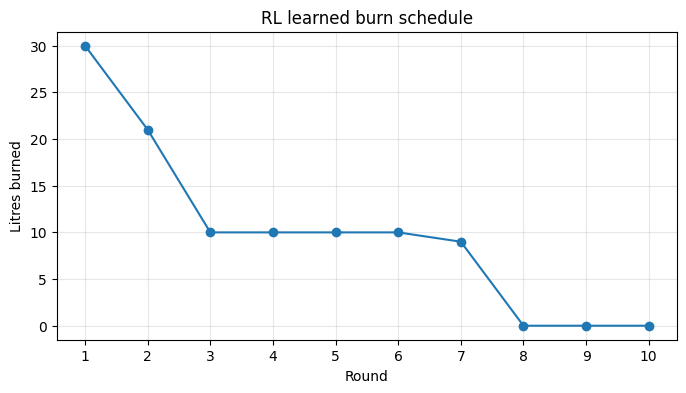

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(burns) + 1), burns, marker="o")
plt.title("RL learned burn schedule")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(range(1, len(burns) + 1))
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

In [26]:
def make_racingfuel_env(seed=0, normalize_obs=True):
    def _init():
        env = RacingFuelDiscreteGymEnv(
            horizon=10,
            init_fuel=100.0,
            energy_per_litre=1.0,
            friction=0.90,
            max_burn=30.0,
            action_step_litres=1.0,
            normalize_obs=normalize_obs,
            seed=seed
        )
        env = Monitor(env)
        return env
    return _init

In [27]:
eval_env = DummyVecEnv([make_racingfuel_env(seed=0, normalize_obs=True)])
print("Eval env obs space:", eval_env.observation_space)
print("Model obs space:", model.observation_space)

Eval env obs space: Box(0.0, 1.0, (3,), float32)
Model obs space: Box(0.0, 1.0, (3,), float32)


In [28]:
final_mean, final_std = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=200,
    deterministic=True
)

print(f"Final model return: {final_mean:.6f} ± {final_std:.6f}")

Final model return: 76.830155 ± 0.000000


In [29]:
candidate_paths = [
    "./rf_dqn_logs/best_model/best_model.zip",
    "./rf_clean_dqn/best_model/best_model.zip",
    "./rf_dqn_logs_fixed/best_model/best_model.zip"
]

best_model_path = None
for p in candidate_paths:
    if os.path.exists(p):
        best_model_path = p
        break

if best_model_path is None:
    # fallback search
    matches = glob.glob("./**/best_model.zip", recursive=True)
    if matches:
        best_model_path = matches[0]

print("Best model path found:", best_model_path)

if best_model_path is None:
    raise FileNotFoundError("No best_model.zip file was found.")

best_model = DQN.load(best_model_path, env=eval_env)

best_mean, best_std = evaluate_policy(
    best_model,
    eval_env,
    n_eval_episodes=200,
    deterministic=True
)

print(f"Best model return: {best_mean:.6f} ± {best_std:.6f}")

Best model path found: ./rf_dqn_logs/best_model/best_model.zip
Best model return: 76.852839 ± 0.000000


In [30]:
LAGRANGE_OPTIMUM = 76.852839

print(f"Lagrange optimum: {LAGRANGE_OPTIMUM:.6f}")
print(f"Final model:      {final_mean:.6f}")
print(f"Best model:       {best_mean:.6f}")
print(f"Best-model gap:   {LAGRANGE_OPTIMUM - best_mean:.6f}")

Lagrange optimum: 76.852839
Final model:      76.830155
Best model:       76.852839
Best-model gap:   0.000000


In [31]:
single_env = RacingFuelDiscreteGymEnv(
    horizon=10,
    init_fuel=100.0,
    energy_per_litre=1.0,
    friction=0.90,
    max_burn=30.0,
    action_step_litres=1.0,
    normalize_obs=True,
    seed=0
)

In [33]:
def rollout_single_env(env, mdl, seed=0):
    obs, info = env.reset(seed=seed)   # Gym API
    done = False

    burns = []
    rewards = []
    speeds = []
    fuels = []
    energies = []
    actions = []

    total = 0.0

    while not done:
        action, _ = mdl.predict(obs, deterministic=True)   # obs is numpy array
        obs, reward, terminated, truncated, info = env.step(action)

        actions.append(int(action))
        burns.append(float(info["burn"]))
        rewards.append(float(reward))
        speeds.append(float(info["speed"]))
        fuels.append(float(info["fuel"]))
        energies.append(float(env.base_env.energy))

        total += float(reward)
        done = terminated or truncated

    return {
        "total_return": total,
        "actions": np.array(actions),
        "burns": np.array(burns),
        "rewards": np.array(rewards),
        "speeds": np.array(speeds),
        "fuels": np.array(fuels),
        "energies": np.array(energies),
    }

In [34]:
final_roll = rollout_single_env(single_env, model, seed=0)
best_roll  = rollout_single_env(single_env, best_model, seed=0)

print("Final total return:", final_roll["total_return"])
print("Final burn schedule:", final_roll["burns"].tolist())

print("Best total return:", best_roll["total_return"])
print("Best burn schedule:", best_roll["burns"].tolist())

Final total return: 76.83015456201286
Final burn schedule: [30.0, 30.0, 29.0, 11.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Best total return: 76.85283893797144
Best burn schedule: [30.0, 30.0, 30.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


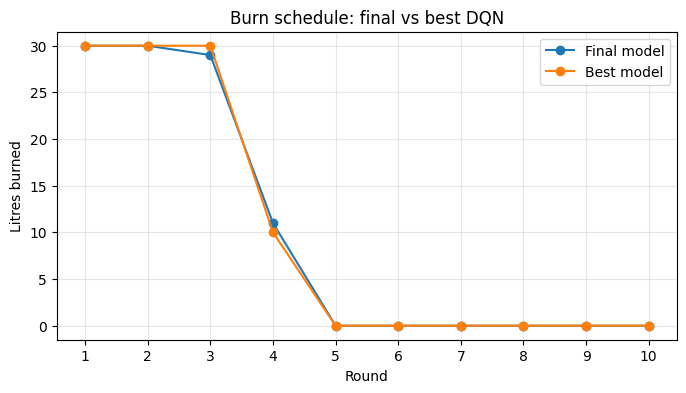

In [35]:
rounds = np.arange(1, 11)

plt.figure(figsize=(8, 4))
plt.plot(rounds, final_roll["burns"], marker="o", label="Final model")
plt.plot(rounds, best_roll["burns"], marker="o", label="Best model")
plt.title("Burn schedule: final vs best DQN")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

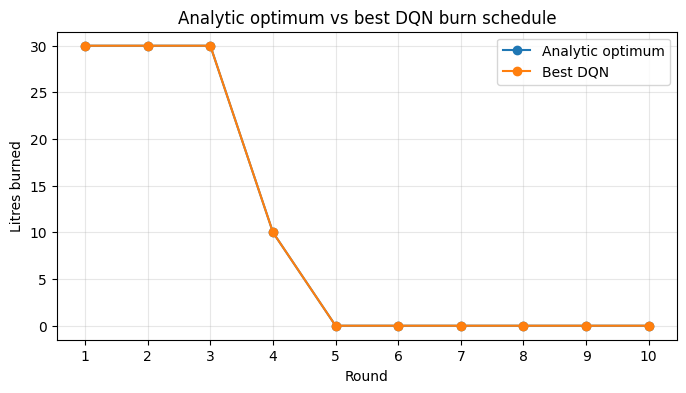

In [36]:
optimal_burns = np.array([30.0, 30.0, 30.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

plt.figure(figsize=(8, 4))
plt.plot(rounds, optimal_burns, marker="o", label="Analytic optimum")
plt.plot(rounds, best_roll["burns"], marker="o", label="Best DQN")
plt.title("Analytic optimum vs best DQN burn schedule")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

evaluations.npz found at: ./rf_clean_dqn/evaluations.npz


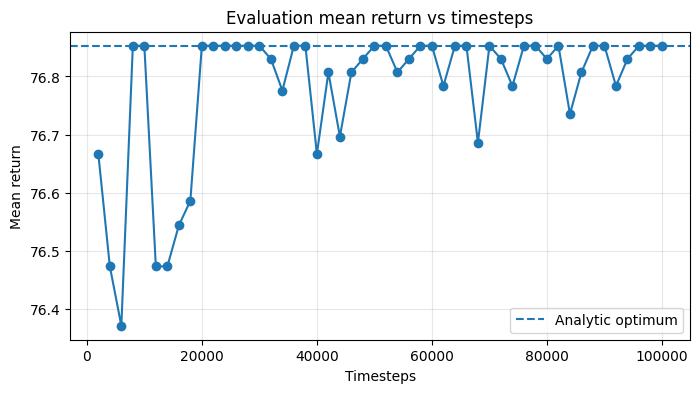

In [37]:
eval_npz = None
possible_eval_files = [
    "./rf_dqn_logs/evaluations.npz",
    "./rf_clean_dqn/evaluations.npz",
    "./rf_dqn_logs_fixed/evaluations.npz",
    "./rf_dqn_logs/eval/evaluations.npz",
    "./rf_clean_dqn/eval/evaluations.npz",
    "./rf_dqn_logs_fixed/eval/evaluations.npz",
]

for p in possible_eval_files:
    if os.path.exists(p):
        eval_npz = p
        break

if eval_npz is None:
    matches = glob.glob("./**/evaluations.npz", recursive=True)
    if matches:
        eval_npz = matches[0]

print("evaluations.npz found at:", eval_npz)

if eval_npz is not None:
    data = np.load(eval_npz)
    timesteps = data["timesteps"]
    results = data["results"]
    mean_returns = np.mean(results, axis=1)

    plt.figure(figsize=(8, 4))
    plt.plot(timesteps, mean_returns, marker="o")
    plt.axhline(LAGRANGE_OPTIMUM, linestyle="--", label="Analytic optimum")
    plt.title("Evaluation mean return vs timesteps")
    plt.xlabel("Timesteps")
    plt.ylabel("Mean return")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("No evaluations.npz file found.")

In [41]:
# Drag-sensitive optimiser references from race_demo_drag.ipynb
# ------------------------------------------------------------
# The continuous SLSQP optimum uses fractional litre values.
# The DQN uses one-litre actions, so DQN comparisons use the
# rounded integer-feasible benchmark.

drag_continuous_optimum_burns = np.array(
    [30.000, 20.883, 9.793, 9.793, 9.793, 9.793, 9.793, 0.152, 0.000, 0.000],
    dtype=float
)

drag_integer_benchmark_burns = np.array(
    [30, 21, 10, 9, 10, 10, 10, 0, 0, 0],
    dtype=float
)

DRAG_CONTINUOUS_OPTIMUM = 62.848043
DRAG_INTEGER_BENCHMARK = 62.847405

print("Continuous SLSQP optimum burns:", drag_continuous_optimum_burns.tolist())
print("Continuous SLSQP optimum return:", DRAG_CONTINUOUS_OPTIMUM)

print("\nRounded integer-feasible benchmark burns:", drag_integer_benchmark_burns.tolist())
print("Rounded integer-feasible benchmark return:", DRAG_INTEGER_BENCHMARK)

print("\nDQN uses one-litre discrete actions, so it is compared against the integer-feasible benchmark.")

Continuous SLSQP optimum burns: [30.0, 20.883, 9.793, 9.793, 9.793, 9.793, 9.793, 0.152, 0.0, 0.0]
Continuous SLSQP optimum return: 62.848043

Rounded integer-feasible benchmark burns: [30.0, 21.0, 10.0, 9.0, 10.0, 10.0, 10.0, 0.0, 0.0, 0.0]
Rounded integer-feasible benchmark return: 62.847405

DQN uses one-litre discrete actions, so it is compared against the integer-feasible benchmark.


In [42]:
def rollout_single_env_drag(env, mdl, seed=0):
    obs, info = env.reset(seed=seed)
    done = False

    burns = []
    rewards = []
    speeds = []
    fuels = []
    energies = []
    retentions = []
    actions = []

    total = 0.0

    while not done:
        action, _ = mdl.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        actions.append(int(action))
        burns.append(float(info["burn"]))
        rewards.append(float(reward))
        speeds.append(float(info["speed"]))
        fuels.append(float(info["fuel"]))
        energies.append(float(info["energy_after"]))
        retentions.append(float(info["retention"]))

        total += float(reward)
        done = terminated or truncated

    return {
        "total_return": total,
        "actions": np.array(actions),
        "burns": np.array(burns),
        "rewards": np.array(rewards),
        "speeds": np.array(speeds),
        "fuels": np.array(fuels),
        "energies": np.array(energies),
        "retentions": np.array(retentions),
    }

In [18]:
drag_single_env = RacingFuelDiscreteGymEnv(**env_kwargs)

drag_roll = rollout_single_env_drag(drag_single_env, best_model, seed=SEED)

print("DQN total return under drag-sensitive dynamics:", drag_roll["total_return"])
print("DQN burn schedule:", drag_roll["burns"].tolist())

DQN total return under drag-sensitive dynamics: 62.846641811892
DQN burn schedule: [30.0, 21.0, 10.0, 10.0, 10.0, 10.0, 9.0, 0.0, 0.0, 0.0]


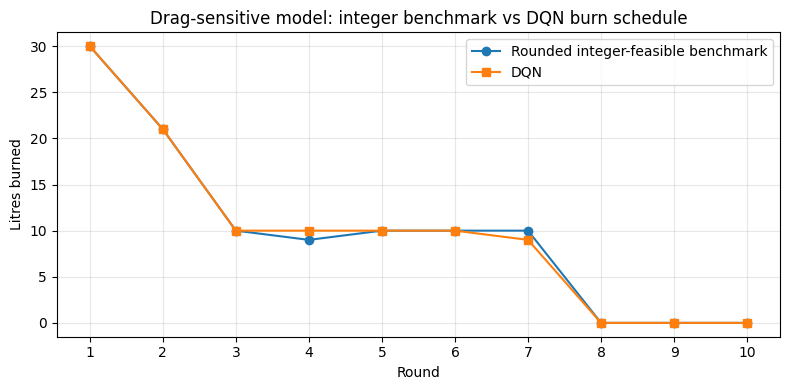

In [19]:
rounds = np.arange(1, len(drag_integer_benchmark_burns) + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    rounds,
    drag_integer_benchmark_burns,
    marker="o",
    label="Rounded integer-feasible benchmark"
)
plt.plot(
    rounds,
    drag_roll["burns"],
    marker="s",
    label="DQN"
)
plt.title("Drag-sensitive model: integer benchmark vs DQN burn schedule")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("drag_dqn_vs_integer_benchmark_burns.png", dpi=300, bbox_inches="tight")
plt.show()

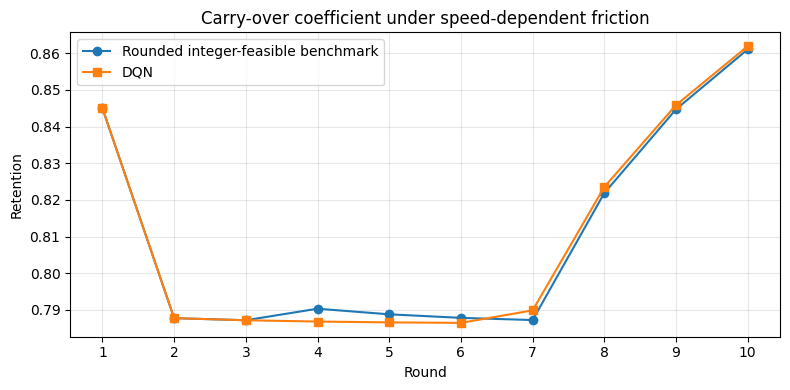

In [20]:
# Compute the benchmark retention path by replaying the rounded integer-feasible schedule
opt_env = RacingFuelEnv(
    horizon=env_kwargs["horizon"],
    init_fuel=env_kwargs["init_fuel"],
    energy_per_litre=env_kwargs["energy_per_litre"],
    friction=env_kwargs["friction"],
    max_burn=env_kwargs["max_burn"],
    retention_mode=env_kwargs["retention_mode"],
    drag_base_retention=env_kwargs["drag_base_retention"],
    drag_coeff=env_kwargs["drag_coeff"],
    drag_min_retention=env_kwargs["drag_min_retention"],
    drag_max_retention=env_kwargs["drag_max_retention"],
    seed=SEED
)

opt_env.reset()
opt_retentions = []
opt_energies = []

for b in drag_integer_benchmark_burns:
    _, _, done, info = opt_env.step(float(b))
    opt_retentions.append(info["retention"])
    opt_energies.append(info["energy_after"])
    if done:
        break

opt_retentions = np.array(opt_retentions)
opt_energies = np.array(opt_energies)

plt.figure(figsize=(8, 4))
plt.plot(
    rounds,
    opt_retentions,
    marker="o",
    label="Rounded integer-feasible benchmark"
)
plt.plot(
    rounds,
    drag_roll["retentions"],
    marker="s",
    label="DQN"
)
plt.title("Carry-over coefficient under speed-dependent friction")
plt.xlabel("Round")
plt.ylabel("Retention")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("drag_retention_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

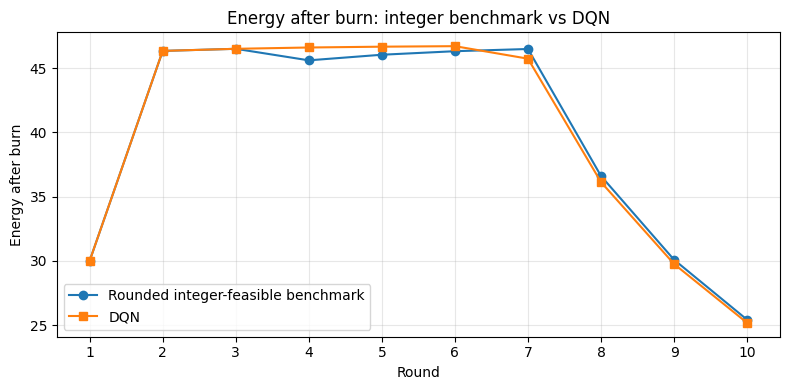

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(
    rounds,
    opt_energies,
    marker="o",
    label="Rounded integer-feasible benchmark"
)
plt.plot(
    rounds,
    drag_roll["energies"],
    marker="s",
    label="DQN"
)
plt.title("Energy after burn: integer benchmark vs DQN")
plt.xlabel("Round")
plt.ylabel("Energy after burn")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("drag_energy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
## Multi-seed DQN search for drag-sensitive environment

In [43]:
# Fair benchmark for DQN because DQN actions are integer litres
# The continuous optimum is reported as an upper reference only.
DRAG_INTEGER_BENCHMARK = 62.847405
DRAG_CONTINUOUS_OPTIMUM = 62.848043

print("Rounded integer-feasible benchmark:", DRAG_INTEGER_BENCHMARK)
print("Continuous SLSQP optimum:", DRAG_CONTINUOUS_OPTIMUM)
print("DQN gap should be measured against the integer-feasible benchmark.")

Rounded integer-feasible benchmark: 62.847405
Continuous SLSQP optimum: 62.848043
DQN gap should be measured against the integer-feasible benchmark.


In [45]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv
import os
import numpy as np

def make_env_with_kwargs(seed, env_kwargs_local):
    def _init():
        local_kwargs = dict(env_kwargs_local)
        local_kwargs["seed"] = seed
        env = RacingFuelDiscreteGymEnv(**local_kwargs)
        env = Monitor(env)
        return env
    return _init


def train_one_drag_dqn(
    seed,
    env_kwargs_local,
    total_timesteps=250_000,
    learning_rate=1e-4,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=128,
    gamma=1.0,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=500,
    exploration_fraction=0.4,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.02,
    net_arch=[128, 128],
    root_log_dir="./rf_drag_multiseed"
):
    run_dir = os.path.join(root_log_dir, f"seed_{seed}")
    best_dir = os.path.join(run_dir, "best_model")
    os.makedirs(best_dir, exist_ok=True)

    train_env_local = DummyVecEnv([make_env_with_kwargs(seed, env_kwargs_local)])
    eval_env_local = DummyVecEnv([make_env_with_kwargs(seed + 1000, env_kwargs_local)])

    eval_callback_local = EvalCallback(
        eval_env_local,
        best_model_save_path=best_dir,
        log_path=run_dir,
        eval_freq=5000,
        n_eval_episodes=100,
        deterministic=True,
        render=False,
        verbose=0
    )

    model_local = DQN(
        policy="MlpPolicy",
        env=train_env_local,
        learning_rate=learning_rate,
        buffer_size=buffer_size,
        learning_starts=learning_starts,
        batch_size=batch_size,
        gamma=gamma,
        train_freq=train_freq,
        gradient_steps=gradient_steps,
        target_update_interval=target_update_interval,
        exploration_fraction=exploration_fraction,
        exploration_initial_eps=exploration_initial_eps,
        exploration_final_eps=exploration_final_eps,
        policy_kwargs=dict(net_arch=net_arch),
        verbose=0,
        seed=seed,
        device="auto"
    )

    model_local.learn(
        total_timesteps=total_timesteps,
        callback=eval_callback_local,
        progress_bar=True
    )

    best_path = os.path.join(best_dir, "best_model.zip")
    best_model_local = DQN.load(best_path, env=eval_env_local)

    mean_ret, std_ret = evaluate_policy(
        best_model_local,
        eval_env_local,
        n_eval_episodes=200,
        deterministic=True
    )

    return {
        "seed": seed,
        "run_dir": run_dir,
        "best_path": best_path,
        "mean_return": float(mean_ret),
        "std_return": float(std_ret),
        "gap_to_integer_benchmark": float(DRAG_INTEGER_BENCHMARK - mean_ret),
        "model": best_model_local
    }

In [46]:
results = []

for s in [0, 1, 2]:
    print(f"\n===== Training seed {s} =====")
    res = train_one_drag_dqn(
        seed=s,
        env_kwargs_local=env_kwargs,
        total_timesteps=250_000
    )
    results.append(res)
    print(
        f"Seed {s} -> mean_return={res['mean_return']:.6f}, "
        f"gap_to_integer_benchmark={res['gap_to_integer_benchmark']:.6f}"
    )


===== Training seed 0 =====


Seed 0 -> mean_return=62.846689, gap_to_integer_benchmark=0.000716

===== Training seed 1 =====


Seed 1 -> mean_return=62.844991, gap_to_integer_benchmark=0.002414

===== Training seed 2 =====


Seed 2 -> mean_return=62.844663, gap_to_integer_benchmark=0.002742


In [44]:
# Multi-seed DQN summary
# ----------------------
# If the full multi-seed training cell has been run in this kernel, use `results`.
# Otherwise, use the recorded values from the completed runs.

if "results" in globals() and len(results) > 0:
    best_res = max(results, key=lambda x: x["mean_return"])

    seed_returns = np.array([r["mean_return"] for r in results], dtype=float)
    best_seed = best_res["seed"]
    best_return = float(best_res["mean_return"])
    best_eval_std = float(best_res["std_return"])
    best_model_path = best_res["best_path"]

else:
    # Recorded values from the completed multi-seed runs
    seed_returns = np.array([62.846689, 62.844991, 62.844663], dtype=float)

    best_seed = 0
    best_return = float(np.max(seed_returns))
    best_eval_std = 0.0
    best_model_path = "./rf_drag_multiseed/seed_0/best_model/best_model.zip"

    best_res = {
        "seed": best_seed,
        "mean_return": best_return,
        "std_return": best_eval_std,
        "best_path": best_model_path,
        "gap_to_integer_benchmark": DRAG_INTEGER_BENCHMARK - best_return
    }

seed_mean = float(np.mean(seed_returns))
seed_std = float(np.std(seed_returns, ddof=1))  # sample standard deviation

print("=== Multi-seed DQN summary ===")
print("Seed returns:", [round(x, 6) for x in seed_returns.tolist()])
print(f"Mean return: {seed_mean:.6f}")
print(f"Sample standard deviation: {seed_std:.6f}")

print("\n=== Best DQN run ===")
print("Best seed:", best_seed)
print(f"Best return: {best_return:.6f}")
print(f"Best-run std from evaluate_policy: {best_eval_std:.6f}")
print(f"Gap to rounded integer-feasible benchmark: {DRAG_INTEGER_BENCHMARK - best_return:.6f}")
print("Best model path:", best_model_path)

if not os.path.exists(best_model_path):
    print("\nWARNING: Best model file was not found at this path.")
    print("If you need the final multi-seed plot, rerun the multi-seed training cell or check the path.")

=== Multi-seed DQN summary ===
Seed returns: [62.846689, 62.844991, 62.844663]
Mean return: 62.845448
Sample standard deviation: 0.001087

=== Best DQN run ===
Best seed: 0
Best return: 62.846689
Best-run std from evaluate_policy: 0.000000
Gap to rounded integer-feasible benchmark: 0.000716
Best model path: ./rf_drag_multiseed/seed_0/best_model/best_model.zip


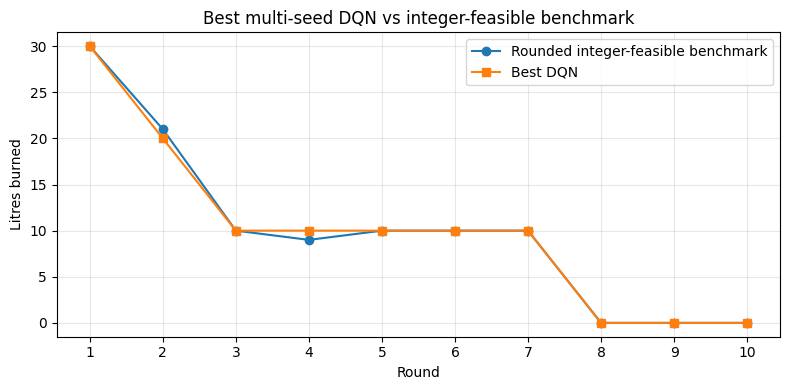

Saved figure:
 - drag_multiseed_dqn_vs_integer_benchmark.png
Best DQN return: 62.846689
Integer-feasible benchmark return: 62.847405
Gap: 0.000716


In [45]:
# Best multi-seed DQN vs rounded integer-feasible benchmark
# This uses the confirmed multi-seed results from the completed drag-sensitive runs.
# It avoids reloading/retraining the DQN and only recreates the final comparison figure.

import numpy as np
import matplotlib.pyplot as plt

rounds = np.arange(1, 11)

# Rounded integer-feasible SLSQP benchmark used for fair DQN comparison
drag_integer_benchmark_burns = np.array(
    [30, 21, 10, 9, 10, 10, 10, 0, 0, 0],
    dtype=float
)

# Best multi-seed DQN burn schedule from completed seed search
best_dqn_burns = np.array(
    [30, 20, 10, 10, 10, 10, 10, 0, 0, 0],
    dtype=float
)

plt.figure(figsize=(8, 4))

plt.plot(
    rounds,
    drag_integer_benchmark_burns,
    marker="o",
    label="Rounded integer-feasible benchmark"
)

plt.plot(
    rounds,
    best_dqn_burns,
    marker="s",
    label="Best DQN"
)

plt.title("Best multi-seed DQN vs integer-feasible benchmark")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("drag_multiseed_dqn_vs_integer_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:")
print(" - drag_multiseed_dqn_vs_integer_benchmark.png")
print("Best DQN return: 62.846689")
print("Integer-feasible benchmark return: 62.847405")
print("Gap: 0.000716")